In [1]:
import sys
sys.path.append("../../")

%load_ext autoreload
%autoreload 2

In [2]:
import dsrl.offline_safety_gymnasium  # type: ignore
import gymnasium as gym
import joblib
import math
import functools

import dsrl.infos as dsrl_infos
import numpy as np
import jax
import jax.numpy as jnp
from flax import nnx

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# t-SNE plot import
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

from mpl_toolkits.mplot3d import Axes3D

from dsrl_model.utils.buffer_jax import SafeCLBuffer
from dsrl_model.utils.models_jax import ExpCostModel, TransformerEmbedding, l2_normalize
from dsrl_model.utils.dsrl_dataset import get_dataset_in_d4rl_format, get_pos_neg_and_union_data, get_normalized_data

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [3]:
def get_data(data, start=0, end=-1):
    observations, actions, costs = data["observations"], data["actions"], data["costs"]
    end = end if end < 0 else min(end, observations.shape[0])
    return (jnp.array(observations[start:end]),
            jnp.array(actions[start:end]),
            jnp.array(costs[start:end]))

In [4]:
def construct_buffer(data, obs_dim, act_dim, horizon, batch):
    ep_len = 1000
    pos_data, neg_data, union_data = data
    
    buffer = SafeCLBuffer(
        rngs=jax.random.PRNGKey(0),
        obs_dim=obs_dim,
        act_dim=act_dim,
        pos_data_size=np.prod(pos_data["observations"].shape[:-1]),
        neg_data_size=np.prod(neg_data["observations"].shape[:-1]),
        union_data_size=np.prod(union_data["observations"].shape[:-1]),
        horizon=horizon,
        batch_size=batch,
        ep_len=ep_len,
    )
    
    pos_observations = pos_data["observations"]
    pos_actions = pos_data["actions"]
    pos_dones = pos_data["timeouts"] | pos_data["terminals"]
    pos_rewards = pos_data["rewards"]
    pos_costs = pos_data["costs"]

    for obs, act, done, reward, cost in zip(
        pos_observations, pos_actions, pos_dones, pos_rewards, pos_costs
    ):
        buffer.add(obs, act, done, reward, cost, is_pos=True)
        
    neg_observations = neg_data["observations"]
    neg_actions = neg_data["actions"]
    neg_dones = neg_data["timeouts"] | neg_data["terminals"]
    neg_rewards = neg_data["rewards"]
    neg_costs = neg_data["costs"]

    for obs, act, done, reward, cost in zip(
        neg_observations, neg_actions, neg_dones, neg_rewards, neg_costs
    ):
        buffer.add(obs, act, done, reward, cost, is_neg=True)

    union_observations = union_data["observations"]
    union_actions = union_data["actions"]
    union_dones = union_data["timeouts"] | union_data["terminals"]
    union_rewards = union_data["rewards"]
    union_costs = union_data["costs"]
    
    for obs, act, done, reward, cost in zip(
        union_observations, union_actions, union_dones, union_rewards, union_costs
    ):
        buffer.add(obs, act, done, reward, cost, is_union=True)
        
    buffer.to_jax_ndarray()
    data_buffer = buffer.get_data_buffer()
    return data_buffer

In [5]:
def load_cost_model(obs_dim, act_dim, hidden_size, path):
    restored_pure_dict = joblib.load(path)
    
    model = ExpCostModel(
        rngs=nnx.Rngs(0), x_dims=(obs_dim + act_dim), hidden_size=hidden_size
    )
    abstract_model = nnx.eval_shape(lambda: model)
    graphdef, abstract_state = nnx.split(abstract_model)
    nnx.replace_by_pure_dict(abstract_state, restored_pure_dict)
    cost_model = nnx.merge(graphdef, abstract_state)
    cost_model.eval()
    return cost_model


def load_embedding_model(obs_dim, act_dim, horizon, embd_dim, num_attentions, path):
    restored_pure_dict = joblib.load(path)
    restored_pure_dict.pop('mask')
    restored_pure_dict.pop('pos_encoding')
    
    model = TransformerEmbedding(
        rngs=nnx.Rngs(0), 
        obs_dim=obs_dim,
        act_dim=act_dim,
        horizon=horizon,
        embd_dim=embd_dim,
        num_attentions=num_attentions,
    )
    abstract_model = nnx.eval_shape(lambda: model)
    graphdef, abstract_state = nnx.split(abstract_model)
    nnx.replace_by_pure_dict(abstract_state, restored_pure_dict)
    embedding_model = nnx.merge(graphdef, abstract_state)
    
    embedding_model.mask = jnp.tril(jnp.ones((horizon, horizon)))
    embedding_model.pos_encoding = positionalencoding1d(embd_dim, horizon)
    
    embedding_model.eval()
    return embedding_model

In [6]:
def get_env(task):
    env = gym.make(task)
    obs_space, act_space = env.observation_space, env.action_space
    return env, obs_space.shape[0], act_space.shape[0]

In [7]:
@nnx.jit
def get_embedding(embedding_model, observations, actions, norm=False):
    observations, actions = jnp.array(observations), jnp.array(actions)
 
    def normalize(obs):
        mu, std = jnp.mean(obs, axis=(0, 1)), jnp.std(obs, axis=(0,1))
        return (obs - mu) / (std + 1e-6)

    observations = jnp.where(norm, normalize(observations), observations)
    z = embedding_model(jnp.concat([observations, actions], axis=-1), training=False)
    return z


@jax.jit
def get_true_cost(costs):
    costs = jnp.array(costs)
    return jnp.sum(costs, axis=1).squeeze()
    

@nnx.jit
def get_pred_cost(cost_model, observations, actions, norm=False):
    observations, actions = jnp.array(observations), jnp.array(actions)
 
    def normalize(obs):
        mu, std = jnp.mean(obs, axis=(0, 1)), jnp.std(obs, axis=(0,1))
        return (obs - mu) / (std + 1e-6)

    observations = jnp.where(norm, normalize(observations), observations)
    transition_cost = cost_model(jnp.concat([observations, actions], axis=-1))
    trajectory_cost = jnp.sum(transition_cost, axis=1).squeeze()
    return trajectory_cost


def get_tsne_vectors(group_embeddings, dim=3, seed=0, do_norm=False):
    tsne = TSNE(n_components=dim, perplexity=50, random_state=seed, init='random')
    
    embds_size = [embds.shape[0] for embds in group_embeddings]
    embds_ends = np.cumsum(embds_size)
    group_embeddings = np.concatenate(group_embeddings, axis=0)
    vec = tsne.fit_transform(group_embeddings)
    if do_norm:
        vec = vec / np.linalg.norm(vec, axis=1, keepdims=True)
    
    group_vec = []
    for i in range(len(embds_ends)):
        start = 0 if i==0 else embds_ends[i-1]
        end = embds_ends[i]
        group_vec.append(vec[start:end])

    return group_vec

In [8]:
trajectory_cfg = {
    "density": 1.0,
    "target_cost": 25.0,
    # ((low_cost, low_reward), (high_cost, low_reward), (medium_cost, high_reward))
    "inpaint_ranges": None,
    "num_positive_trajectories": 1,
    "num_negative_trajectories": 5,
    "num_union_trajectories": 500,
    "non_pref_noise": 0,
    "data_inpaint": "full",
    "inpaint_ranges": None,
}

In [9]:
seed = 0

task_name = "Swimmer_Velocity"
ver = 1
tn = task_name.replace("_", "")
task = f"Offline{tn}Gymnasium-v{ver}"

gamma = 0.99

is_norm = True
norm_type = "norm" if is_norm else "no_norm"

hidden_size = 256

embd_dim = 128
horizon = 1000
num_attentions = 3

eps = 1e-6

neg_z_path = f"/home/returaj/workspace/github/offline_mpc/dsrl_model/runs/safecl/{task}/{norm_type}/state.pkl"
embedding_path = f"/home/returaj/workspace/github/offline_mpc/dsrl_model/runs/safecl/{task}/{norm_type}/embedding_model_1000000.pt"
cost_path = f"/home/returaj/workspace/github/offline_mpc/dsrl_model/runs/safecl/{task}/{norm_type}/cost_model_1000000.pt"

In [10]:
np.random.seed(seed=seed)
key = jax.random.PRNGKey(0)

In [11]:
del pos_data, neg_data, union_data

NameError: name 'pos_data' is not defined

Loading dataset from /home/returaj/.dsrl/datasets/SafetySwimmerVelocityGymnasium-v1-200-1686.hdf5


load datafile: 100%|██████████| 7/7 [00:01<00:00,  6.65it/s]


rmax = 238.95831298828125, rmin = 0.07114458084106445
cmax = 200.0, cmin = 0.0
before filter: traj num = 1686, transitions num = 1686000
after filter: traj num = 1686


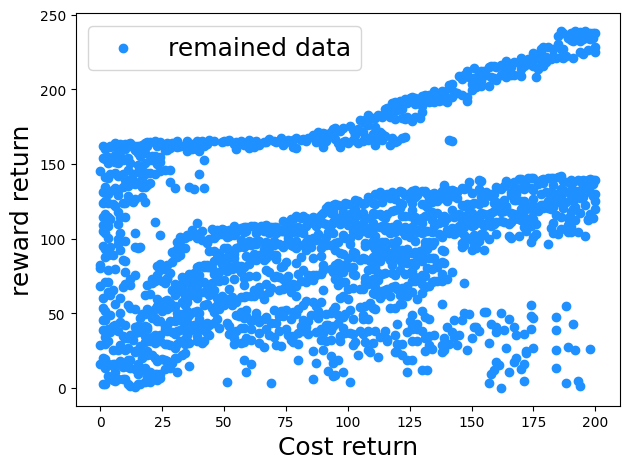

In [12]:
env, obs_dim, act_dim = get_env(task)
main_data = get_dataset_in_d4rl_format(env, trajectory_cfg, task, 1000)

Number of true negative trajectory dataset: 5
Number of false negative trajectory dataset: 0
Number of union trajectory dataset: 500
Avg union trajectory cost/reward: 90.136/101.247
Number of positive trajectory dataset: 1
Avg positive trajectory cost/reward: 6.000/163.701
Number of negative trajectory dataset: 5
Avg negative trajectory cost/reward: 113.800/90.660


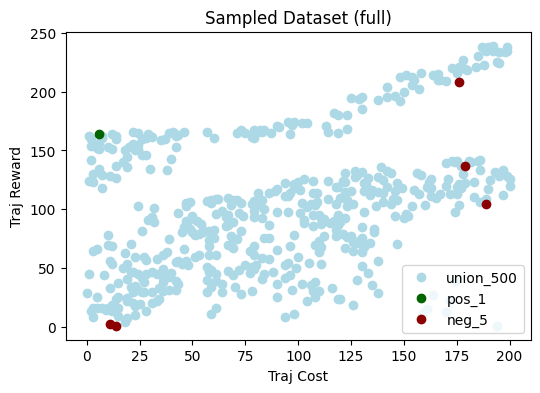

In [13]:
pos_data, neg_data, union_data = get_pos_neg_and_union_data(main_data, trajectory_cfg)

if is_norm:
    pos_data, neg_data, union_data, mu_obs, std_obs = get_normalized_data(
        pos_data, neg_data, union_data
    )

del main_data

In [14]:
hz = 50

In [15]:
data_buffer = construct_buffer((pos_data, neg_data, union_data), obs_dim, act_dim, hz, 64)

In [16]:
key, subkey = jax.random.split(key)
pos_idxs, neg_idxs, union_idxs = data_buffer.sample_idxs(data_buffer, subkey, 100)

In [17]:
def batch(i, key, curriculum_embedding_model, embedding_model):
    data = data_buffer.sample_batch(data_buffer, pos_idxs[i], neg_idxs[i], union_idxs[i])
    pos = jnp.concat([data.pos_obs, data.pos_act], axis=-1)
    neg = jnp.concat([data.neg_obs, data.neg_act], axis=-1)
    union = jnp.concat([data.union_obs, data.union_act], axis=-1)

    key1, key2, key3, key4 = jax.random.split(key, 4)
    mix_p = jax.random.uniform(key=key1, shape=union.shape)
    runion = jax.random.permutation(key2, union, axis=0)
    random = mix_p * runion + (1 - mix_p) * union
    
    outval = jax.random.normal(
        key3, shape=union.shape, dtype=jnp.float32,
    )

    # B X embd
    zpos = curriculum_embedding_model.z(pos, training=False)
    print((zpos[0] @ zpos[0].T).mean())
    zpos = zpos[:, -1, :]
    zneg = curriculum_embedding_model.z(neg, training=False)[:, -1, :]
    zunion = curriculum_embedding_model.z(union, training=False)[:, -1, :]
    zrandom = curriculum_embedding_model.z(random, training=False)[:, -1, :]
    zoutval = curriculum_embedding_model.z(outval, training=False)[:, -1, :]
    zunion_ne = embedding_model.z(union, training=False)[:, -1, :]
    
    zrandn = zpos + 0.01 * jax.random.normal(key4, shape=zpos.shape)
    
    zs = (zpos, zneg, zunion, zrandom, zoutval, zunion_ne, zrandn)
    
    pos_neg = zpos @ zneg.T
    pos_union = zpos @ zunion.T
    neg_union = zneg @ zunion.T
    union_union = zunion @ zunion.T
    random_union = zrandom @ zunion.T
    out_pos = zoutval @ zpos.T
    embd_curr = zunion_ne @ zunion.T
    
    pos_randn = zpos @ zrandn.T
    
    pos_neg_val = (pos_neg.min(), pos_neg.max(), pos_neg.mean(), pos_neg.std())
    pos_union_val = (pos_union.min(), pos_union.max(), pos_union.mean(), pos_union.std())
    neg_union_val = (neg_union.min(), neg_union.max(), neg_union.mean(), neg_union.std())
    union_union_val = (union_union.min(), union_union.max(), union_union.mean(), union_union.std())
    random_union_val = (random_union.min(), random_union.max(), random_union.mean(), random_union.std())
    out_pos_val = (out_pos.min(), out_pos.max(), out_pos.mean(), out_pos.std())
    embd_curr_val = (embd_curr.min(), embd_curr.max(), embd_curr.mean(), embd_curr.std())
    pos_randn_val = (pos_randn.min(), pos_randn.max(), pos_randn.mean(), pos_randn.std())
    
    vals = (pos_neg_val, pos_union_val, neg_union_val, union_union_val, random_union_val, out_pos_val, embd_curr_val, pos_randn_val)
    
    return zs, vals

In [18]:
def plot_statistics(
    pos_neg_val,
    pos_union_val,
    neg_union_val,
    union_union_val,
    random_union_val,
    out_pos_val,
    embd_curr_val,
    pos_randn_val,
    title,
    fontsize=10,
):
    # Compute statistics
    stats = {
        "pos_neg": pos_neg_val,
        "pos_union": pos_union_val,
        "neg_union": neg_union_val,
        "union_union": union_union_val,
        "random_union": random_union_val,
        "out_pos": out_pos_val,
        "embd_curr": embd_curr_val,
        "pos_randn": pos_randn_val,
    }

    labels = list(stats.keys())

    mins  = np.array([v[0] for v in stats.values()])
    maxs  = np.array([v[1] for v in stats.values()])
    means = np.array([v[2] for v in stats.values()])
    stds  = np.array([v[3] for v in stats.values()])

    x = np.arange(len(labels))

    fig, ax = plt.subplots(figsize=(10, 6))

    # Main bars with std error bars
    bars = ax.bar(x, means, yerr=stds, capsize=6)

    # Mark min values
    ax.scatter(x, mins,marker="_", s=400, label="min")

    # Mark max values
    ax.scatter(x, maxs, marker="_", s=400, label="max")

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=10, fontsize=fontsize)
    ax.set_ylabel("Cosin Similarity", fontsize=fontsize)
    ax.set_title(title, fontsize=fontsize)

    ax.legend()

    plt.tight_layout()
    plt.show()

In [19]:
embedding_model = TransformerEmbedding(
    rngs=nnx.Rngs(params=seed, dropout=seed + 1),
    obs_dim=obs_dim,
    act_dim=act_dim,
    horizon=hz,
    embd_dim=128,
    num_attentions=2,
    do_layer_norm=True,
    do_residual=True,
)

curriculum_embedding_model = TransformerEmbedding(
    rngs=nnx.Rngs(params=seed + 42, dropout=seed + 47),
    obs_dim=obs_dim,
    act_dim=act_dim,
    horizon=hz,
    embd_dim=128,
    num_attentions=3,
    do_layer_norm=True,
    do_residual=False,
)

In [20]:
zs, vals = batch(15, key, curriculum_embedding_model, embedding_model)

0.956344


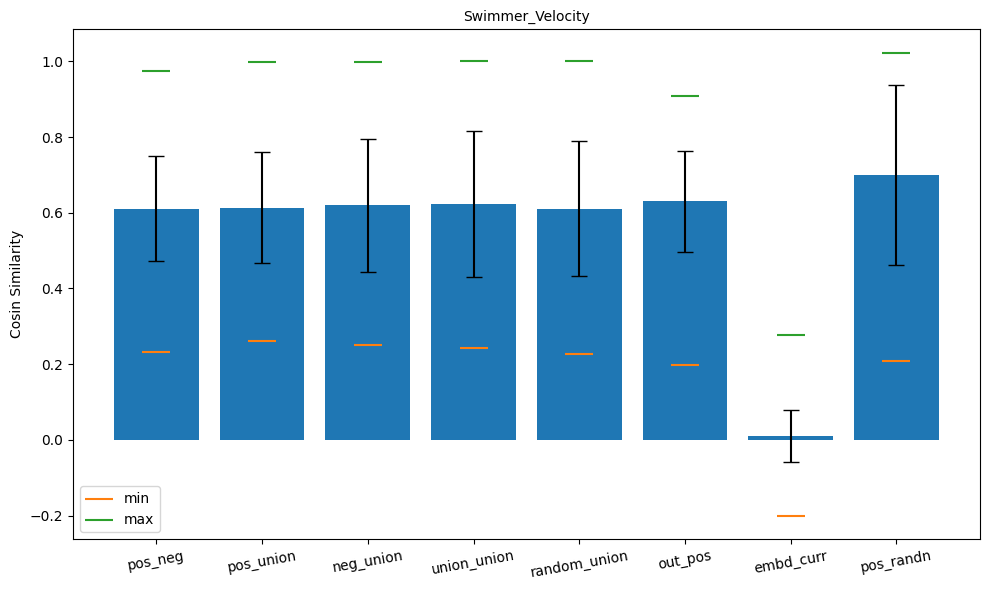

In [21]:
plot_statistics(*vals, f"{task_name}")

#### Curriculum embedding plot

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA


def sphere_vmf_plot(X):

    # -------------------------------------------------
    # Mean direction on hypersphere
    # -------------------------------------------------

    mu = X.mean(axis=0)
    mu = mu / np.linalg.norm(mu)

    # -------------------------------------------------
    # Tangent projection
    #
    # remove radial component
    # -------------------------------------------------

    X_tangent = X - (X @ mu[:, None]) * mu

    # -------------------------------------------------
    # PCA in tangent plane
    # -------------------------------------------------

    pca = PCA(n_components=2)

    Y = pca.fit_transform(X_tangent)

    # -------------------------------------------------
    # Convert tangent coordinates -> sphere
    #
    # z controls spherical cap appearance
    # -------------------------------------------------

    scale = np.max(np.linalg.norm(Y, axis=1))

    Y = Y / scale

    x = Y[:, 0]
    y = Y[:, 1]

    r2 = x**2 + y**2

    # upper hemisphere embedding
    z = np.sqrt(np.clip(1 - r2, 0, 1))

    # -------------------------------------------------
    # Plot
    # -------------------------------------------------

    fig = plt.figure(figsize=(5, 5))
    ax = fig.add_subplot(111, projection='3d')

    ax.set_position([0, 0, 1, 1])

    ax.scatter(
        x,
        y,
        z,
        color='#B57BB3',
        s=14,
    )

    # sphere
    u = np.linspace(0, 2*np.pi, 100)
    v = np.linspace(0, np.pi, 100)

    xs = np.outer(np.cos(u), np.sin(v))
    ys = np.outer(np.sin(u), np.sin(v))
    zs = np.outer(np.ones_like(u), np.cos(v))

    ax.plot_surface(
        xs, ys, zs,
        color='lightgray',
        alpha=0.06,
        linewidth=0
    )

    ax.set_axis_off()

    ax.set_box_aspect([1,1,1])

    # IMPORTANT:
    # view slightly below north pole
    ax.view_init(elev=18, azim=30)
    
    # IMPORTANT: zoom in
    ax.dist = 5

    # remove all outer padding
    plt.margins(0)
    plt.subplots_adjust(
        left=0,
        right=1,
        bottom=0,
        top=1
    )
    plt.savefig(
        "sphere.svg",
        bbox_inches="tight",
        pad_inches=0,
        dpi=300,
        format="svg",
    )

    plt.show()

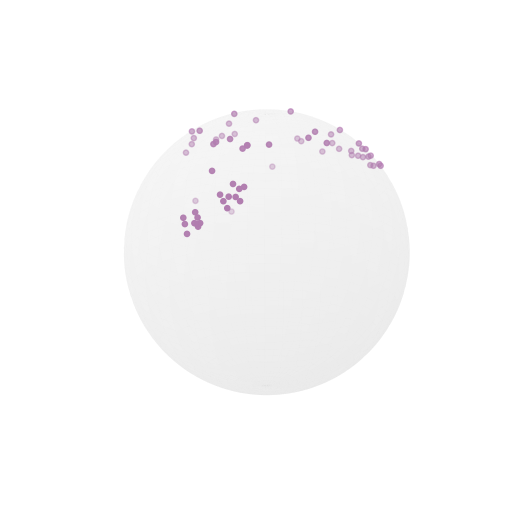

In [23]:
sphere_vmf_plot(zs[2])

### Curriculum Model Collapse

In [24]:
def get_collapse_values(key, hz, num_layers, embd_sizes):
    obs_dim, act_dim = 10, 5
    
    X = jax.random.normal(
        key, shape=(100, hz, obs_dim + act_dim), dtype=jnp.float32,
    )
    
    ret = {"hz":{}, "last":{}}
    for embd in embd_sizes:
        curr_model = TransformerEmbedding(
            rngs=nnx.Rngs(params=seed + 42, dropout=seed + 47),
            obs_dim=obs_dim,
            act_dim=act_dim,
            horizon=hz,
            embd_dim=embd,
            num_attentions=num_layers,
            do_layer_norm=True,
            do_residual=False,
        )
        
        # B X H X embd
        z = curr_model.z(X, training=False)

        # B X H X H
        hz_zsim = jnp.matmul(z, jnp.transpose(z, axes=(0, 2, 1)))
        # B
        hz_collapse = jax.vmap(lambda x: x.mean())(hz_zsim)
        
        # B X embd
        zlast = z[:,-1,:]
        # B X B
        zlast_collapse = (zlast) @ zlast.T

        ret["hz"][embd] = (hz_collapse.mean(), hz_collapse.std())
        ret["last"][embd] = (zlast_collapse.mean(), zlast_collapse.std())

    return ret

In [25]:
def plot_statistics(
    stats,
    title,
    plt_name,
    fontsize=10,
):
    
    labels = list(stats.keys())

    means  = np.array([v[0] for v in stats.values()])
    stds  = np.array([v[1] for v in stats.values()])

    x = np.arange(len(labels))

    fig, ax = plt.subplots(figsize=(4, 2.5))

    # Main bars with std error bars
    bars = ax.bar(x, means, yerr=stds, capsize=6)

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=10, fontsize=fontsize)
    ax.set_xlabel("Embedding Size", fontsize=fontsize)
    ax.set_ylabel("Cosin Similarity", fontsize=fontsize)
    ax.set_title(title, fontsize=fontsize)

    plt.tight_layout()
    plt.show()
    fig.savefig(f'../{plt_name}', format="pdf", bbox_inches='tight')
    
    

In [26]:
hz, num_layers = 50, 10

In [27]:
val = get_collapse_values(key, hz, num_layers, embd_sizes=[64, 128, 512, 1000, 2000])

In [132]:
# val["hz"]

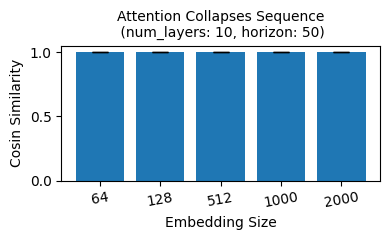

In [28]:
plot_statistics(
    stats=val["hz"],
    title=f"Attention Collapses Sequence\n (num_layers: {num_layers}, horizon: {hz})",
    plt_name=f"attn_collapse_L{num_layers}.pdf"
)

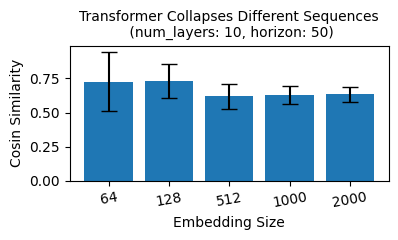

In [29]:
plot_statistics(
    stats=val["last"],
    title=f"Transformer Collapses Different Sequences\n (num_layers: {num_layers}, horizon: {hz})",
    plt_name=f"tf_collapse_L{num_layers}.pdf"
)

In [13]:
model1 = TransformerEmbedding(
        rngs=nnx.Rngs(0), 
        obs_dim=obs_dim,
        act_dim=act_dim,
        horizon=100,
        embd_dim=embd_dim,
        num_attentions=num_attentions,
    )

model2 = TransformerEmbedding(
        rngs=nnx.Rngs(13), 
        obs_dim=obs_dim,
        act_dim=act_dim,
        horizon=100,
        embd_dim=embd_dim,
        num_attentions=3,

    )

In [14]:
key = jax.random.PRNGKey(0)
r = jax.random.normal(key=key, shape=(32, 100, obs_dim+act_dim))

In [15]:
z1 = model1(r, training=False)
z2 = model2(r, training=False)

In [16]:
jnp.einsum("ij,ij->i", z1, z2)

Array([ 0.0074787 ,  0.06002655,  0.08689655,  0.09369391,  0.16183268,
        0.09380711,  0.04966401,  0.1115236 ,  0.01988813,  0.09005217,
        0.07070477, -0.07376831,  0.02372983, -0.0107938 ,  0.16768037,
        0.01269658,  0.00111571, -0.0469263 ,  0.00951684,  0.04666883,
        0.05275911,  0.03168996,  0.05763179,  0.06597352,  0.00520258,
        0.07466348,  0.12866458,  0.14035243,  0.02181611,  0.09274537,
        0.12663719,  0.07208955], dtype=float32)

In [19]:
jnp.min(z1 @ z1.T), jnp.mean(z1 @ z1.T)

(Array(0.34987766, dtype=float32), Array(0.60247034, dtype=float32))